# Bridging Gaps in Heliospheric Radio Data Analyses

*authors: L. Grosset and the MASER team*

# Introduction to maser-data

maser-data is a python package (which is included into the maser4py large python package). Both can be installed through pip:

> pip install maser-data
>
>>(or alternatively
>>
>> pip install maser4py[all])

Documentation can be found at pypi and on:

> https://maser.pages.obspm.fr/maser4py/sections/user_guide.html#read-radio-data-with-maser-data

The NASA CDF library is needed (for CDFs)!

# Technical aspects

maser4py is based on class inheritance with specific properties at each level.

> <center>Data</center>
>
> <center>/  . . . . .  \</center>
>
> <center>CdfData . . . FixedFrequencies</center>
>
> <center> \ . . . . .  /</center>
>
> <center>RPW_dataset</center>
>
> <center> |</center>
>
> <center>RpwHfrL3Cdf</center>

Each class level inherits from properties typical for these datasets. For example:

- Data define the general properties and the methods that should be supported (quicklook, as_xarray...)

- CdfData define the usage of Epoch, the metadata giving the dataset ID etc.

- and these are overwritten by the latest level classes if needed (at Solar Orbiter level for example)

- some extremely specific needs are defined for one specific dataset (the keys to be displayed typically)

# Imports

In [ ]:
# -*- coding: utf-8 -*-
# import os
import numpy as np
import matplotlib.pyplot as plt

# importing maser
from maser.data import Data

# NASA CDF lib needs to be installed!
# os.environ["CDF_LIB"] = "/home/lgrosset/Documents/Programmes/CDF/cdf39_0-dist-all/cdf39_0-dist/lib"

# Setting CDF files to be read

In [ ]:
# Put here path to data and filenames
base_dir = "home/directory/data/"  # to adapt
filename = [
    base_dir + "solo_L3_rpw-tnr-surv-flux_20240323_V02.cdf",
    base_dir + "solo_L3_rpw-hfr-surv-flux_20240323_V02.cdf",
]

# Format

maser-data returns *maser* objects

In [3]:
data_rpw_l3_tnr = Data(filename[0])
data_rpw_l3_tnr

These *maser* objects can then be saved and possess a few methods and properties. We indentified the main keys for quick displays, accessible through:

In [4]:
data_rpw_l3_tnr.dataset_keys

['PSD_V2', 'PSD_FLUX', 'PSD_SFU']

# Quicklooks

Quicklooks can be easily generated with:

In [ ]:
data_rpw_l3_tnr.quicklook()

Maser's quicklook routine wrap matplotlib's pyplot pcolormesh, so any arguments that can be given to pcolormesh can be given to quicklook as well:

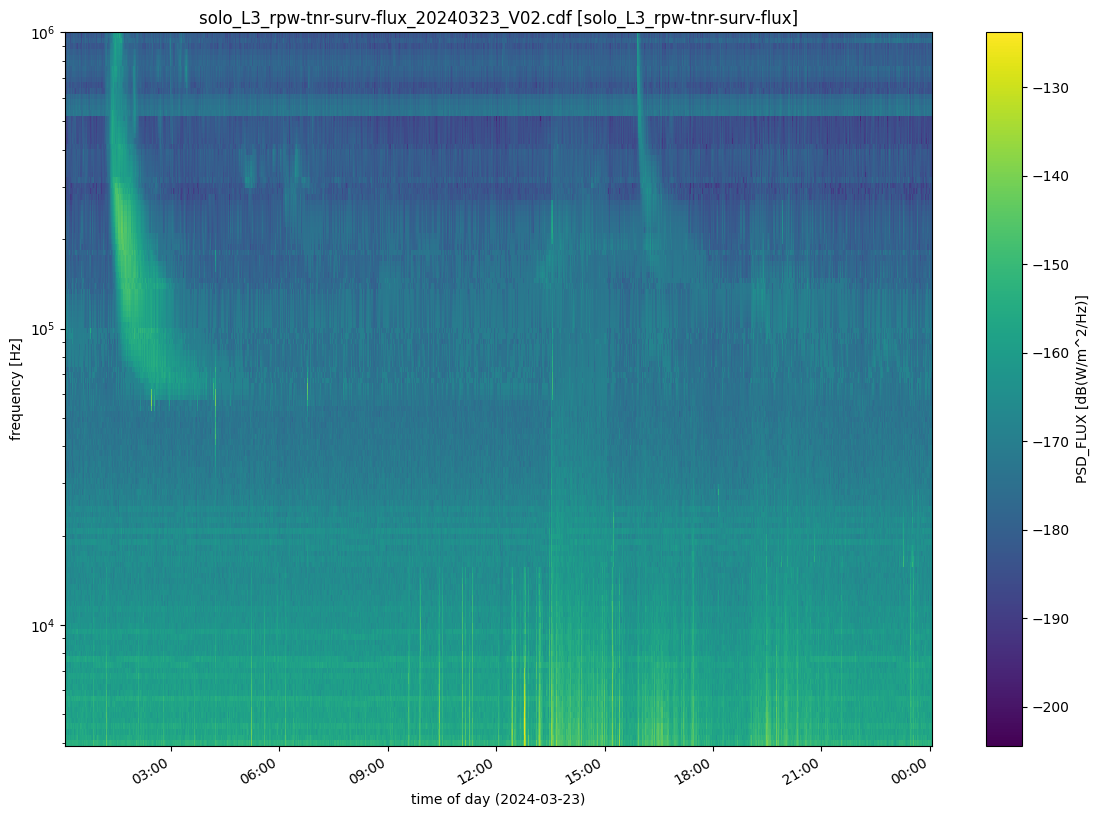

In [6]:
data_rpw_l3_tnr.quicklook(cmap="viridis", yscale = "log")

# Output format

For data analysis, maser-data returns the data loaded from the files into xarrays. This can be done with the as_xarray method, and xarray comes with its own display and properties. as_array returns a xarray.Dataset object:

In [7]:
xar_data_rpw_l3_tnr = data_rpw_l3_tnr.as_xarray()
xar_data_rpw_l3_tnr

<xarray.Dataset>
Dimensions:    (frequency: 128, time: 7322)
Coordinates:
  * frequency  (frequency) float32 3.992e+03 4.169e+03 ... 9.371e+05 9.786e+05
  * time       (time) datetime64[ns] 2024-03-23T00:03:23.688790 ... 2024-03-2...
Data variables:
    PSD_SFU    (frequency, time) float32 5.214e+05 4.893e+05 ... 2.25e+03
    PSD_FLUX   (frequency, time) float32 3.474e-16 3.261e-16 ... 1.604e-18
    PSD_V2     (frequency, time) float32 5.519e-13 5.18e-13 ... 2.548e-15

DataArrays can then be extracted from the Dataset by using the correct key corresponding to the variable name:

In [8]:
xar_data_rpw_l3_tnr["PSD_FLUX"]

<xarray.DataArray 'PSD_FLUX' (frequency: 128, time: 7322)>
array([[3.4743934e-16, 3.2607282e-16, 9.1978027e-16, ..., 3.6858284e-16,
        5.4815674e-16, 6.2123096e-16],
       [1.6272320e-16, 1.8184492e-16, 2.4099914e-16, ..., 2.7083026e-16,
        2.9194134e-16, 2.7370649e-16],
       [1.1156693e-16, 1.9493962e-16, 1.1684982e-16, ..., 1.8293561e-16,
        2.0790024e-16, 1.5683016e-16],
       ...,
       [3.0797904e-19, 8.4820987e-19, 4.5852679e-19, ..., 3.1912245e-19,
        4.4812892e-19, 3.4312936e-19],
       [9.0207117e-19, 4.7055994e-19, 1.0478274e-18, ..., 2.6514050e-18,
        1.5925448e-18, 1.8604851e-18],
       [7.0019381e-19, 4.8657085e-19, 7.8791662e-19, ..., 1.1943433e-18,
        8.7288048e-19, 1.6040430e-18]], dtype=float32)
Coordinates:
  * frequency  (frequency) float32 3.992e+03 4.169e+03 ... 9.371e+05 9.786e+05
  * time       (time) datetime64[ns] 2024-03-23T00:03:23.688790 ... 2024-03-2...
Attributes:
    units:    W/m^2/Hz

Variables attributes can be accessed through:

In [9]:
xar_data_rpw_l3_tnr["PSD_FLUX"].attrs

{'units': 'W/m^2/Hz'}

xarray.DataArray also comes with its own plot function (also based on pcolormesh). This is the same one used by maser-data, but without the settings that improves the spectrograms display.

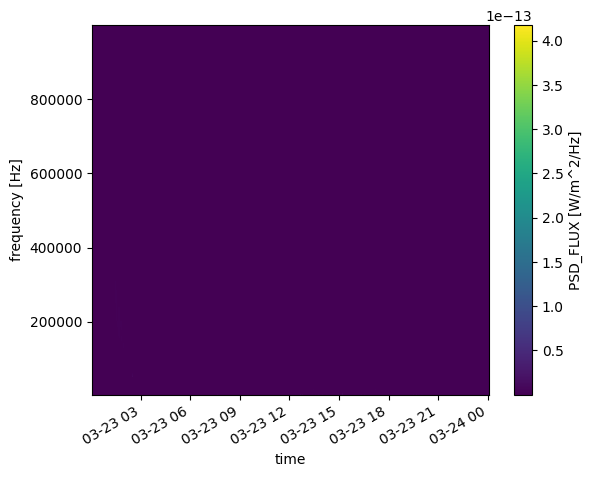

In [10]:
xar_data_rpw_l3_tnr["PSD_FLUX"].plot()

A short way of improving display:

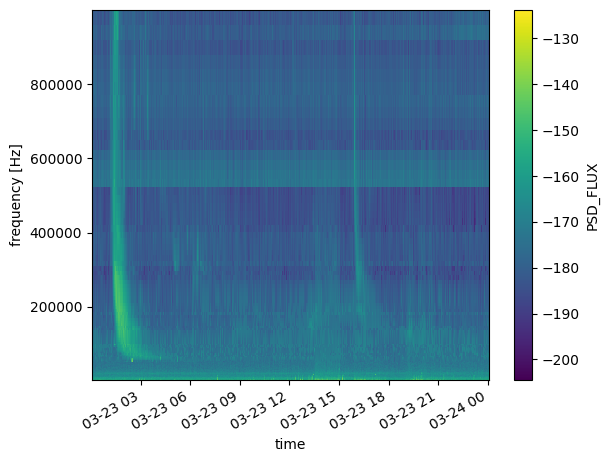

In [11]:
(10.*np.log10(xar_data_rpw_l3_tnr["PSD_FLUX"][...])).plot()

# Advanced plotting

This part presents a few possibilities exploiting xarray possibilities to:
- customize plots,
- play with the data,
- combine datasets (both in xarrays and/or in plots)

First, let's look at different ways of producing plots, from maser quicklook routine and from xarray native plot function, with details or on a short version:

<xarray.Dataset>
Dimensions:    (frequency: 128, time: 7322)
Coordinates:
  * frequency  (frequency) float32 3.992e+03 4.169e+03 ... 9.371e+05 9.786e+05
  * time       (time) datetime64[ns] 2024-03-23T00:03:23.688790 ... 2024-03-2...
Data variables:
    PSD_SFU    (frequency, time) float32 5.214e+05 4.893e+05 ... 2.25e+03
    PSD_FLUX   (frequency, time) float32 3.474e-16 3.261e-16 ... 1.604e-18
    PSD_V2     (frequency, time) float32 5.519e-13 5.18e-13 ... 2.548e-15


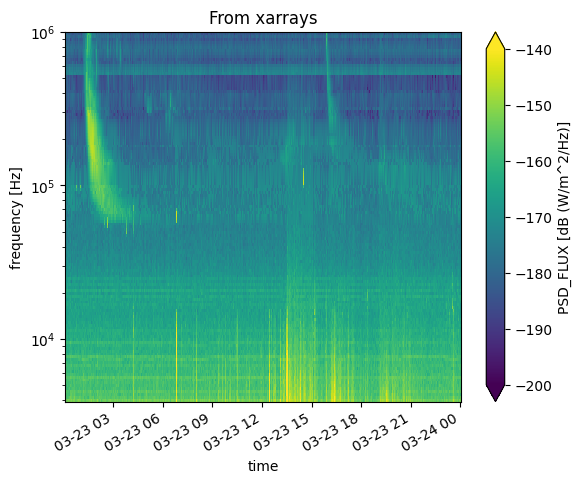

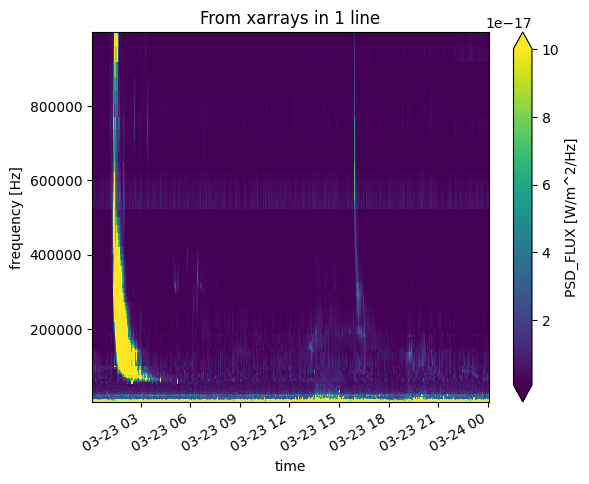

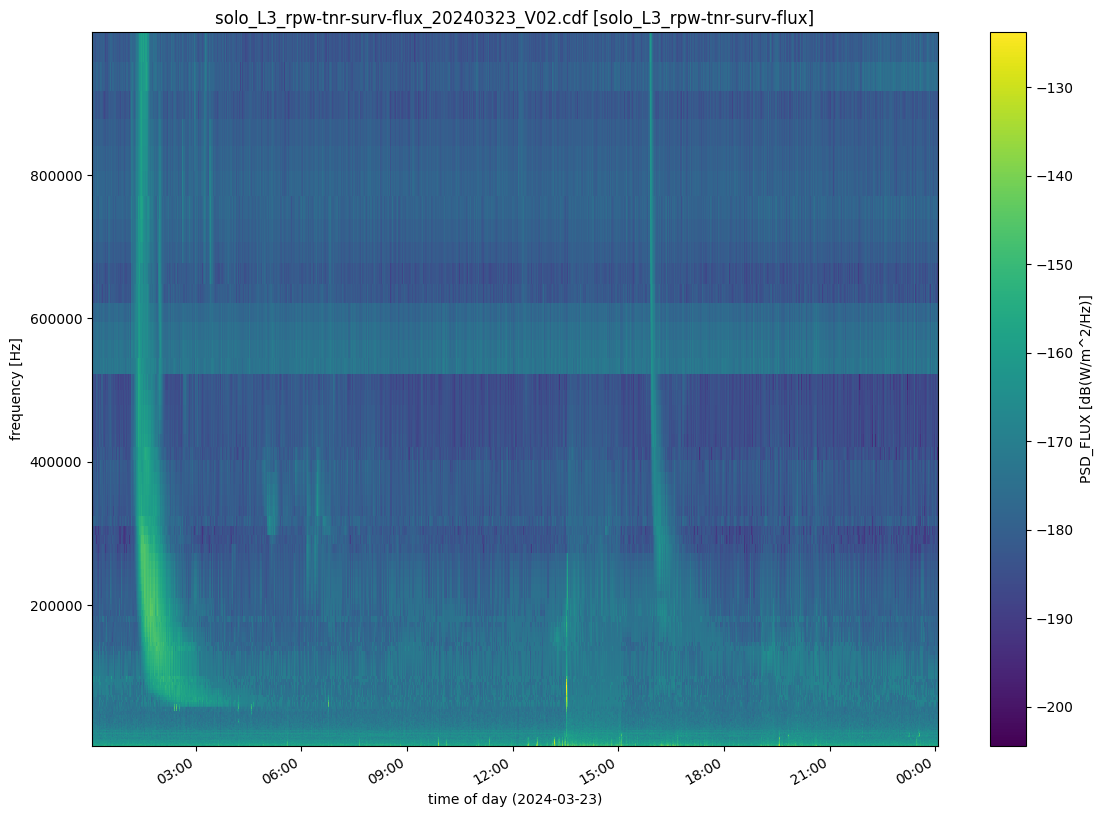

In [12]:
from maser.data import Data
data = Data(filename[0])
print(data.as_xarray())

xd = data.as_xarray()["PSD_FLUX"]
xd.values = 10 * np.log10(xd.values)
xd.attrs["units"] = f"dB ({xd.attrs['units']})"
xd.plot(yscale="log", vmin=-200, vmax=-140)
plt.title("From xarrays")
# plt.savefig("../Plots/images_doc/Example_plotting_xarray.png")
plt.show()

plt.figure()
data.as_xarray()["PSD_FLUX"].plot(vmin=1e-18, vmax=1e-16)
plt.title("From xarrays in 1 line")
# plt.savefig("../Plots/images_doc/Example_plotting_xarray_direct.png")
plt.show()

data.quicklook(keys=["PSD_FLUX"],cmap="viridis",nan_color="black")
# note: savefig does not work because a show() is included in quicklook.
plt.show()

We will now try to load and combine TNR and HFR from Solar Orbiter's RPW.

First we load both datasets:

In [13]:
xar_data_rpw_l3_tnr = data_rpw_l3_tnr.as_xarray()
data_rpw_l3_hfr = Data(filename[1])
xar_data_rpw_l3_hfr = data_rpw_l3_hfr.as_xarray()

and plots:

/home/lgrosset/.venvs/venv_maser4py/lib/python3.10/site-packages/xarray/core/computation.py:771: RuntimeWarning: invalid value encountered in log10
  result_data = func(*input_data)


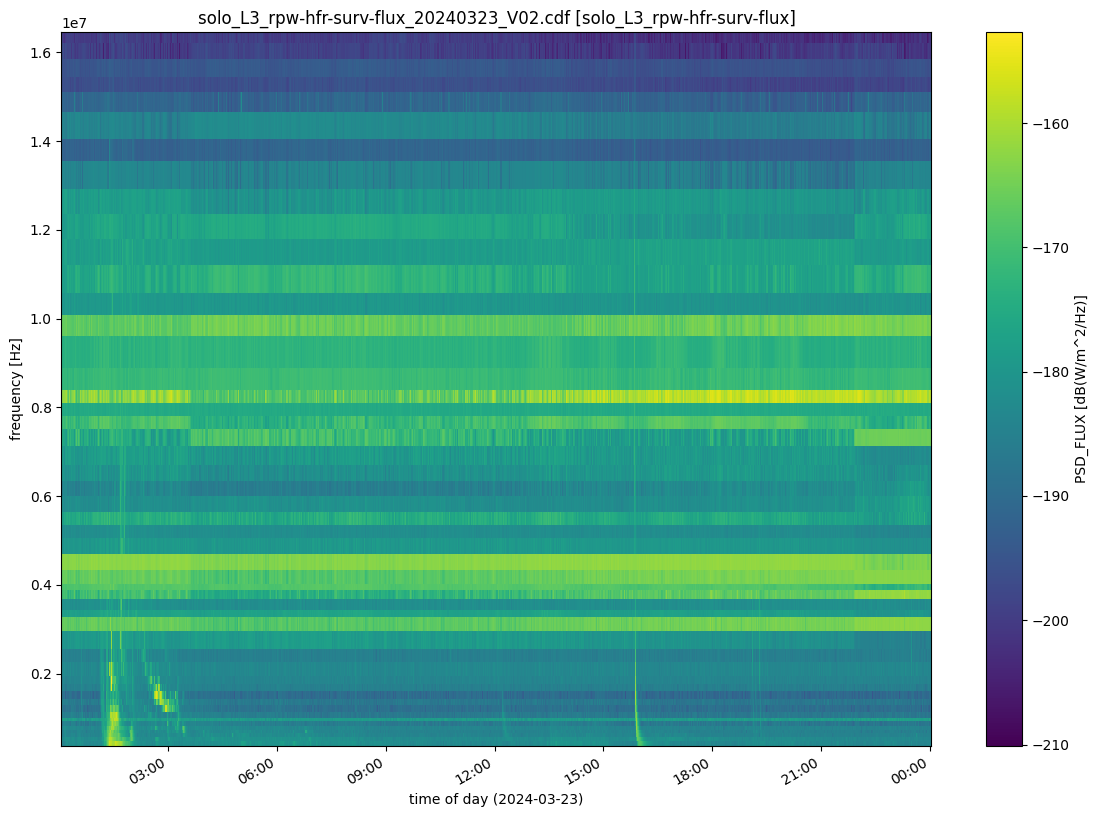

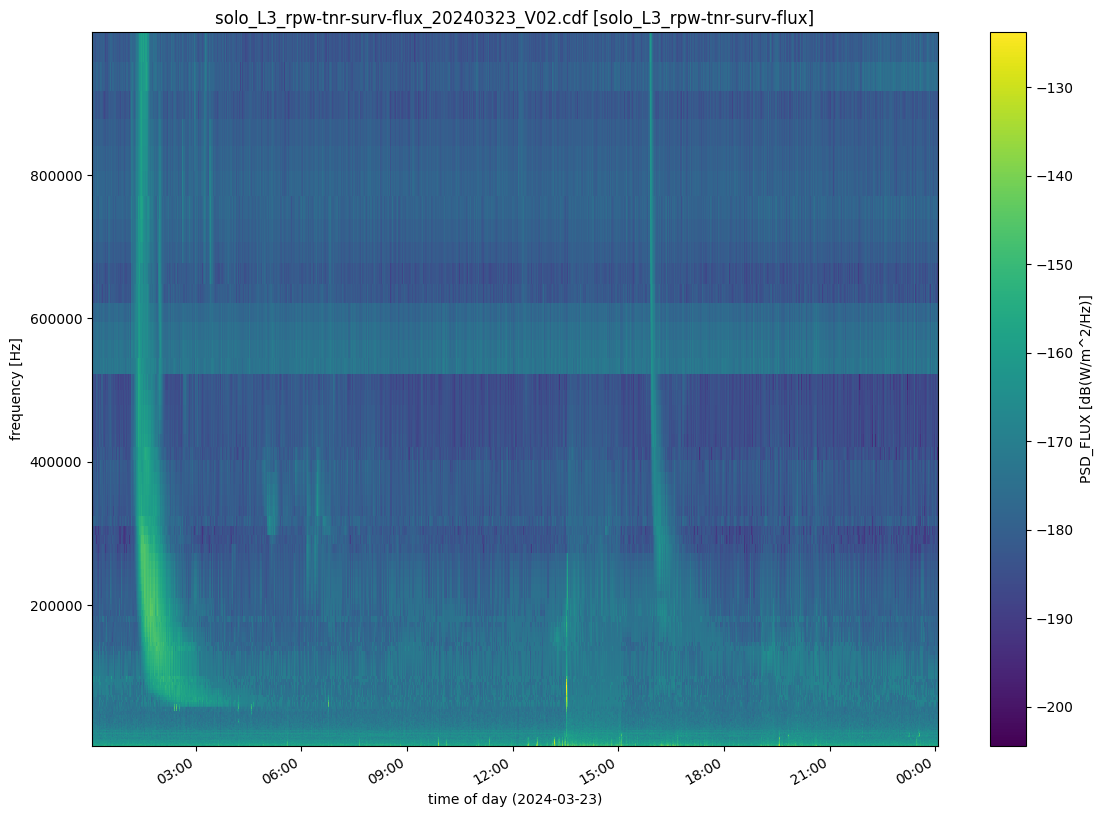

In [14]:
data_rpw_l3_hfr.quicklook(cmap="viridis")
data_rpw_l3_tnr.quicklook(cmap="viridis")

We can formally combine the two xarray Datasets within a single xarray Dataset:

In [15]:
import xarray
xar_thr = xarray.concat([xar_data_rpw_l3_tnr,xar_data_rpw_l3_hfr], dim="frequency")

/home/lgrosset/.venvs/venv_maser4py/lib/python3.10/site-packages/xarray/core/concat.py:527: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))


This will fill all the empty Epoch x frequencies with np.nan:

In [16]:
xar_thr

<xarray.Dataset>
Dimensions:    (time: 23821, frequency: 178)
Coordinates:
  * time       (time) datetime64[ns] 2024-03-23T00:03:04.878572 ... 2024-03-2...
  * frequency  (frequency) float32 3.992e+03 4.169e+03 ... 1.608e+07 1.632e+07
Data variables:
    PSD_SFU    (frequency, time) float32 nan nan nan nan ... 9.224 nan nan nan
    PSD_FLUX   (frequency, time) float32 nan nan nan nan ... nan nan nan
    PSD_V2     (frequency, time) float32 nan nan nan nan ... nan nan nan

Unfortunately, this leads to not great displays:

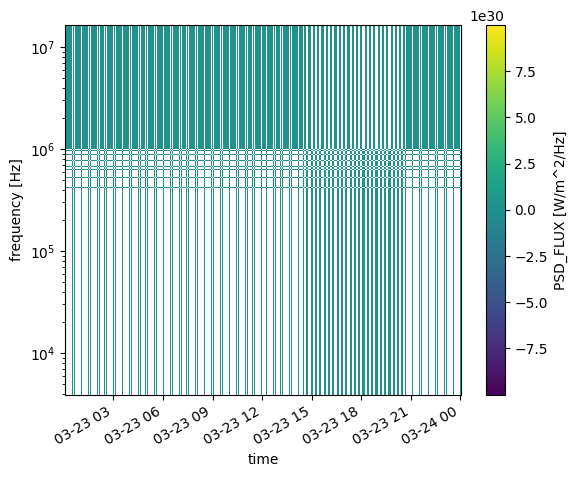

In [17]:
xar_thr["PSD_FLUX"].sortby("time").sortby("frequency").plot(cmap="viridis", yscale="log")

To better combine the datasets in plots, it is better to not combine xarrays and instead plot both datasets on the same figure using pcolormesh:

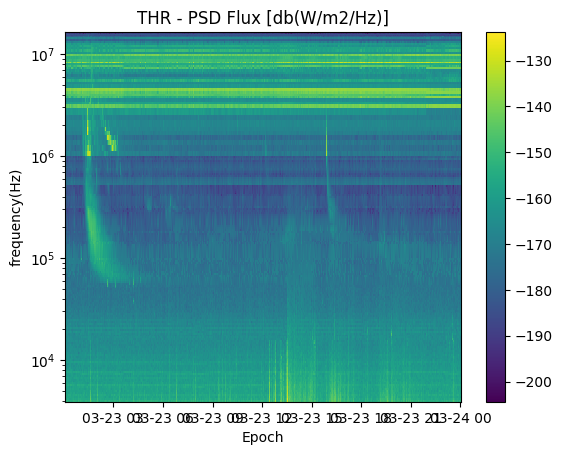

In [18]:
plt.figure()
plt.pcolormesh(xar_data_rpw_l3_hfr["time"],xar_data_rpw_l3_hfr["frequency"],10.*np.log10(xar_data_rpw_l3_hfr["PSD_FLUX"]), cmap="viridis")
plt.yscale("log")
plt.pcolormesh(xar_data_rpw_l3_tnr["time"],xar_data_rpw_l3_tnr["frequency"],10.*np.log10(xar_data_rpw_l3_tnr["PSD_FLUX"]), cmap="viridis")
plt.title("THR - PSD Flux [db(W/m2/Hz)]")
plt.xlabel("Epoch")
plt.ylabel("frequency(Hz)")
plt.colorbar()

*Note: here the figure settings are very basic but can be worked on just like a regular pyplot figure.*

*Second note: The later added figure will be overplotted if some Epoch x frequencies combinations are already displayed from the previous datasets. Here, TNR data replace HFR data for the shared frequencies.*

# The entire set of data supported by maser-data

Below is the entire list, with examples, of all datasets handled with maser-data.

> As maser4py does not handle downloding the data, be aware taht for this notebook to work, you first need to get all of theses datafiles. A link on where these can be found are listed next to each dataset.

*filenames* is a dictionnary containing all the example file names. The keys are the typical dataset names (we tried to match the official ID, but these may not exactly correspond to the exact official ID) and contains both the filename to be loaded by maser and the web address where these data can be found.

In [ ]:
base_dir = "/home/lgrosset/Documents/Astroport/Projets/Maser4py/maser4py/tests/data/"
filenames = {
    "interball": {
        "file": "POLR_RSPN2_19990126",
        "web_location": "https://cdpp-archive.cnes.fr/user/cdpp/modules/1730?d=URN%3AAIP%3ADATA%3Acdpp%3Afa632ec2-221e-3034-9329-987310428b0f%3AV1&eds=QUICKLOOKS&mmv=MODE_3D&mso=true&mss=%5B%7B%22i%22%3A%22%5B1730%2FMAIN_RESULTS%2F2%5D%5B%5D%5B0%3A0%5D%22%2C%22s%22%3A%7B%22searchText%22%3A%22POLR_RSPN2_19990126%22%7D%2C%22r%22%3A%7B%22q%22%3A%22POLR_RSPN2_19990126%22%7D%7D%5D&rd=TABLE&rf=URN%3AAIP%3ADATASET%3Acdpp%3A680488da-d798-4a15-a9d1-80eea18606ac%3AV1&rt=DATA&t=MAIN_RESULTS"
    },
    "stereoA_wave_LFR_l2": {
        "file": "STA_WAV_LFR_20070131.B3E",
        "web_location": "https://cdpp-archive.cnes.fr/user/cdpp/modules/1736?mmv=MODE_3D&mss=%5B%7B%22i%22%3A%22%5B1736%2FMAIN_RESULTS%2F2%5D%5B%5D%5B0%3A0%5D%22%2C%22s%22%3A%7B%22searchText%22%3A%22STA_WAV_LFR_20070131.B3E%22%7D%2C%22r%22%3A%7B%22q%22%3A%22STA_WAV_LFR_20070131.B3E%22%7D%7D%5D&rd=TABLE&rf=URN%3AAIP%3ADATASET%3Acdpp%3A8762dd1f-59a7-403c-a1d6-f9a5bb24a218%3AV1&rt=DATA&t=MAIN_RESULTS",
    },
    "WindWaves_l2": {
        "file": "wi_wa_rad1_l2_19941110_v01.dat",
        "web_location": "https://cdpp-archive.cnes.fr/user/cdpp/modules/1742?mmv=MODE_3D&mss=%5B%7B%22i%22%3A%22%5B1742%2FMAIN_RESULTS%2F2%5D%5B%5D%5B0%3A0%5D%22%2C%22s%22%3A%7B%22searchText%22%3A%22wi_wa_rad1_l2_19941110_v01.dat%22%7D%2C%22r%22%3A%7B%22q%22%3A%22wi_wa_rad1_l2_19941110_v01.dat%22%7D%7D%5D&rd=TABLE&rf=URN%3AAIP%3ADATASET%3Acdpp%3A62a7d4b9-6c39-4eb5-be98-49a1f506d2ed%3AV1&rt=DATA&t=MAIN_RESULTS",
    },
    "ecallisto": {
        "file": "BIR_20220130_111500_01.fit",
        "web_location": "https://soleil.i4ds.ch/solarradio/data/2002-20yy_Callisto/2022/01/30/",
    },
    "NDA_routine_jupiter": {
        "file": "srn_nda_routine_jup_edr_201601302247_201601310645_V12.cdf",
        "web_location": "https://realtime.obs-nancay.fr/dam/databf/web/jupiter/data/2016/01/",
    },
    "NDA_routine_sun": {
        "file": "srn_nda_routine_sun_edr_202305231352_202305231534_V17.cdf",
        "web_location": "https://realtime.obs-nancay.fr/dam/databf/web/soleil/data/2023/05/",
    },
    "NDA_newroutine_jupiter": {
        "file": "orn_nda_newroutine_jup_edr_202303060945_202303061745_v1.1.fits",
        "web_location": "https://cdn.obs-nancay.fr/repository/nda/newroutine/jupiter/2023/03/",
    },
    "NDA_newroutine_sun": {
        "file": "orn_nda_newroutine_sun_edr_202303070802_202303070936_v1.1.fits",
        "web_location": "https://cdn.obs-nancay.fr/repository/nda/newroutine/soleil/2023/03/",
    },
    "NDA_mefisto": {
        "file": "orn_nda_mefisto_sun_edr_202303070802_202303070937_v1.0.fits",
        "web_location": "https://cdn.obs-nancay.fr/repository/nda/mefisto/soleil/2023/03/",
    },
    "NenuFAR_BST": {
        "file": "20220130_112900_BST.fits",
        "web_location": "https://nenufar.obs-nancay.fr/en/astronomer/",
    },
    "BepiColombo_PWI_sorbet_l1": {
        "file": "mmo_pwi_sorbet_l1_ex_specdB-tnr-qtn_20211001_v00.cdf",
        "web_location": "not available yet",
    },
    "expres_juno": {
        "file": "expres_juno_jupiter_ganymede_jrm09_lossc-wid1deg_3kev_20211218_v11.cdf",
        "web_location": "https://maser.obspm.fr/data/expres/juno/2021/12/",
    },
    "expres_earth": {
        "file": "expres_earth_jupiter_io_jrm09_lossc-wid1deg_3kev_20220801_v01.cdf",
        "web_location": "https://maser.obspm.fr/data/expres/earth/2022/08/",
    },
    "Juno_Waves": {
        "file": "jno_wav_cdr_lesia_20170329_v02.cdf",
        "web_location": "https://maser.obspm.fr/repository/juno/waves/data/l3a_v02/data/cdf/2017/03/",
    },
    "Cassini_n1": {
        "file": "n1/R2012180.20",
        "web_location": "https://lesia.obspm.fr/kronos/data/2012_091_180/n1/",
    },
    "Cassini_n2": {
        "file": "n2/P2012180.20",
        "web_location": "https://lesia.obspm.fr/kronos/data/2012_091_180/n2/",
    },
    "Cassini_n3e": {
        "file": "n3e/N3e_dsq2012181.00",
        "web_location": "https://lesia.obspm.fr/kronos/data/2012_181_270/n3e/",
    },
    "Cassini_n3d": {
        "file": "n3d/N3d_dsq2012181.00",
        "web_location": "https://lesia.obspm.fr/kronos/data/2012_181_270/n3d/",
    },
    "SolO_RPW_L2_LFR": {
        "file": "solo_L2_rpw-lfr-surv-bp1_20220326_V04.cdf",
        "web_location": "https://rpw-lira.obspm.fr/roc/data/pub/solo/rpw/data/L2/lfr_bp/2022/03/",
    },
    "SolO_RPW_L2_TNR": {
        "file": "solo_L2_rpw-tnr-surv_20220101_V06.cdf",
        "web_location": "https://rpw-lira.obspm.fr/roc/data/pub/solo/rpw/data/L2/thr/2022/01/",
    },
    "SolO_RPW_L2_HFR": {
        "file": "solo_L2_rpw-hfr-surv_20220101_V04.cdf",
        "web_location": "https://rpw-lira.obspm.fr/roc/data/pub/solo/rpw/data/L2/thr/2022/01/",
    },
    "SolO_RPW_L3_TNR": {
        "file": "solo_L3_rpw-tnr-surv-flux_20230101_V02.cdf",
        "web_location": "https://rpw-lira.obspm.fr/roc/data/pub/solo/rpw/data/L3/thr_flux/2023/01/",
    },
    "SolO_RPW_L3_HFR": {
        "file": "solo_L3_rpw-hfr-surv-flux_20230101_V02.cdf",
        "web_location": "https://rpw-lira.obspm.fr/roc/data/pub/solo/rpw/data/L3/thr_flux/2023/01/",
    },
    "Stereo_Waves_L3": {
        "file": "sta_l3_wav_hfr_20200711_v01.cdf",
        "web_location": "https://maser.obspm.fr/repository/stereo/swaves/sta_wav_hfr_l3_df_v01/cdf/2020/07/",
    },
    "Wind_Waves_L3_akr": {
        "file": "wi_wa_rad1_l3-akr_19990101_v01.cdf",
        "web_location": "https://maser.obspm.fr/doi/10.25935/wxv0-vr90/content/cdf/1999/01/",
    },
    "Wind_Waves_L3_df": {
        "file": "wi_wa_rad1_l3_df_20230523_v02.cdf",
        "web_location": "https://maser.obspm.fr/repository/wind/waves/wi_wa_rad1_l3_df_v02/data/2023/05/",
    },
    "Voyager1_J_PRA_6sec": {
        "file": "VG1-J-PRA-3-RDR-LOWBAND-6SEC-V1/PRA_I.LBL",
        "web_location": "https://maser.obspm.fr/data/voyager/pra/PDS/VG1-J-PRA-3-RDR-LOWBAND-6SEC-V1/DATA/",
    },
    "Voyager1_J_PRA_48sec": {
        "file": "VG1-J-PRA-4-SUMM-BROWSE-48SEC-V1/T790306.LBL",
        "web_location": "https://maser.obspm.fr/data/voyager/pra/PDS/VG1-J-PRA-4-SUMM-BROWSE-48SEC-V1/DATA/",
    },
    "Voyager1_S_PRA_6sec": {
        "file": "VG1-S-PRA-3-RDR-LOWBAND-6SEC-V1/PRA.LBL",
        "web_location": "https://maser.obspm.fr/data/voyager/pra/PDS/VG1-S-PRA-3-RDR-LOWBAND-6SEC-V1/DATA/",
    },
    "Voyager2_N_PRA_6sec": {
        "file": "VG2-N-PRA-3-RDR-LOWBAND-6SEC-V1/VG2_NEP_PRA_6SEC.LBL",
        "web_location": "https://maser.obspm.fr/data/voyager/pra/PDS/VG2-N-PRA-3-RDR-LOWBAND-6SEC-V1/DATA/",
    },
    "MarsExpress_marsis": {
        "file": "FRM_AIS_RDR_13714.LBL",
        "web_location": "https://archives.esac.esa.int/psa/ftp/MARS-EXPRESS/MARSIS/MEX-M-MARSIS-3-RDR-AIS-EXT4-V1.0/DATA/ACTIVE_IONOSPHERIC_SOUNDER/RDR1371X/",
    },
}

You can use any of these keys:

In [20]:
for key in filenames.keys():
    print(key)

interball
stereoA_wave_LFR_l2
WindWaves_l2
ecallisto
NDA_routine_jupiter
NDA_routine_sun
NDA_newroutine_jupiter
NDA_newroutine_sun
NDA_mefisto
NenuFAR_BST
BepiColombo_PWI_sorbet_l1
expres_juno
expres_earth
Juno_Waves
Cassini_n1
Cassini_n2
Cassini_n3e
Cassini_n3d
SolO_RPW_L2_LFR
SolO_RPW_L2_TNR
SolO_RPW_L2_HFR
SolO_RPW_L3_TNR
SolO_RPW_L3_HFR
Stereo_Waves_L3
Wind_Waves_L3_akr
Wind_Waves_L3_df
Voyager1_J_PRA_6sec
Voyager1_J_PRA_48sec
Voyager1_S_PRA_6sec
Voyager2_N_PRA_6sec
MarsExpress_marsis


You can access any data following:

In [22]:
key = "interball"  # put the key you are interested in here from the list above
print(filenames[key]["web_location"])

https://cdpp-archive.cnes.fr/user/cdpp/modules/1730?d=URN%3AAIP%3ADATA%3Acdpp%3Afa632ec2-221e-3034-9329-987310428b0f%3AV1&eds=QUICKLOOKS&mmv=MODE_3D&mso=true&mss=%5B%7B%22i%22%3A%22%5B1730%2FMAIN_RESULTS%2F2%5D%5B%5D%5B0%3A0%5D%22%2C%22s%22%3A%7B%22searchText%22%3A%22POLR_RSPN2_19990126%22%7D%2C%22r%22%3A%7B%22q%22%3A%22POLR_RSPN2_19990126%22%7D%7D%5D&rd=TABLE&rf=URN%3AAIP%3ADATASET%3Acdpp%3A680488da-d798-4a15-a9d1-80eea18606ac%3AV1&rt=DATA&t=MAIN_RESULTS


*Note that Cassini requires a specific folder organisation, look at <https://maser.pages.obspm.fr/maser4py/sections/user_guide.html#co-rpws-hfr-kronos-n3e> if you want tu use Cassini data.*

Now this will work for all datasets, except expres (which is a particular case explained below):

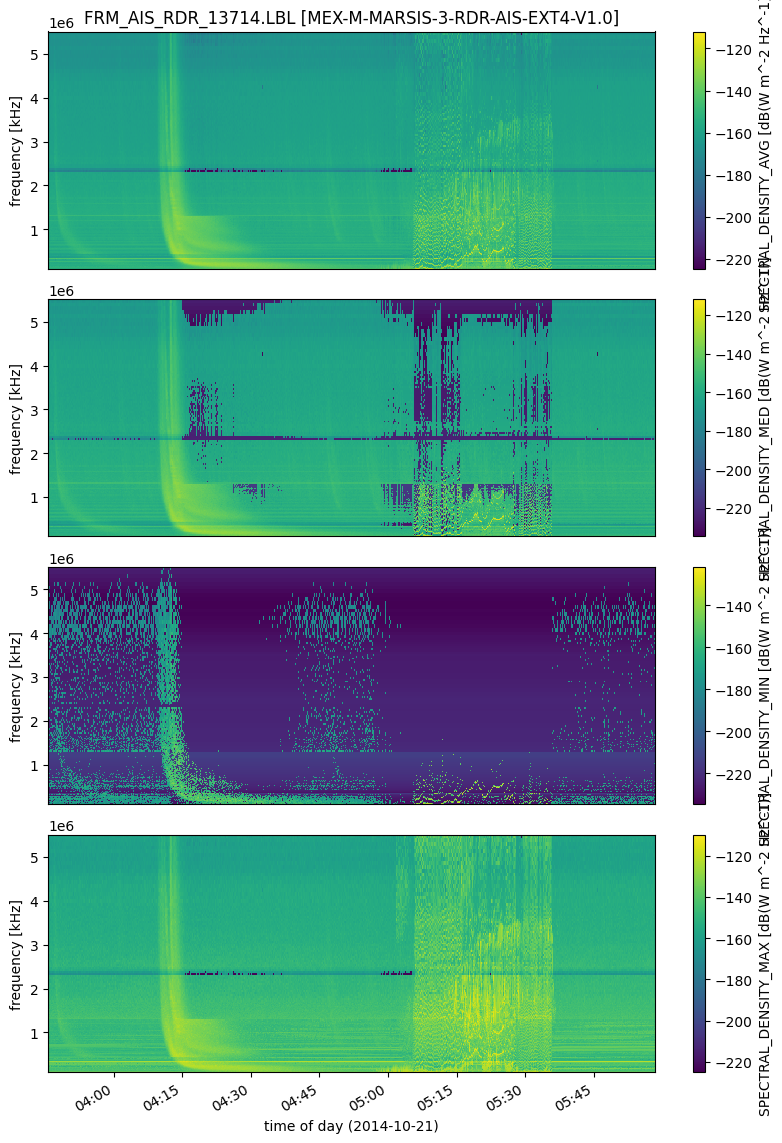

In [ ]:
key = "MarsExpress_marsis"  # put here your dataset key from the list above
data = Data(base_dir + filenames[key]["file"])
data.quicklook(cmap="viridis")

expres (because it is an outpurt of the simulation code expres) datasets require an additionnal parameter, that can be set following:

expres_juno


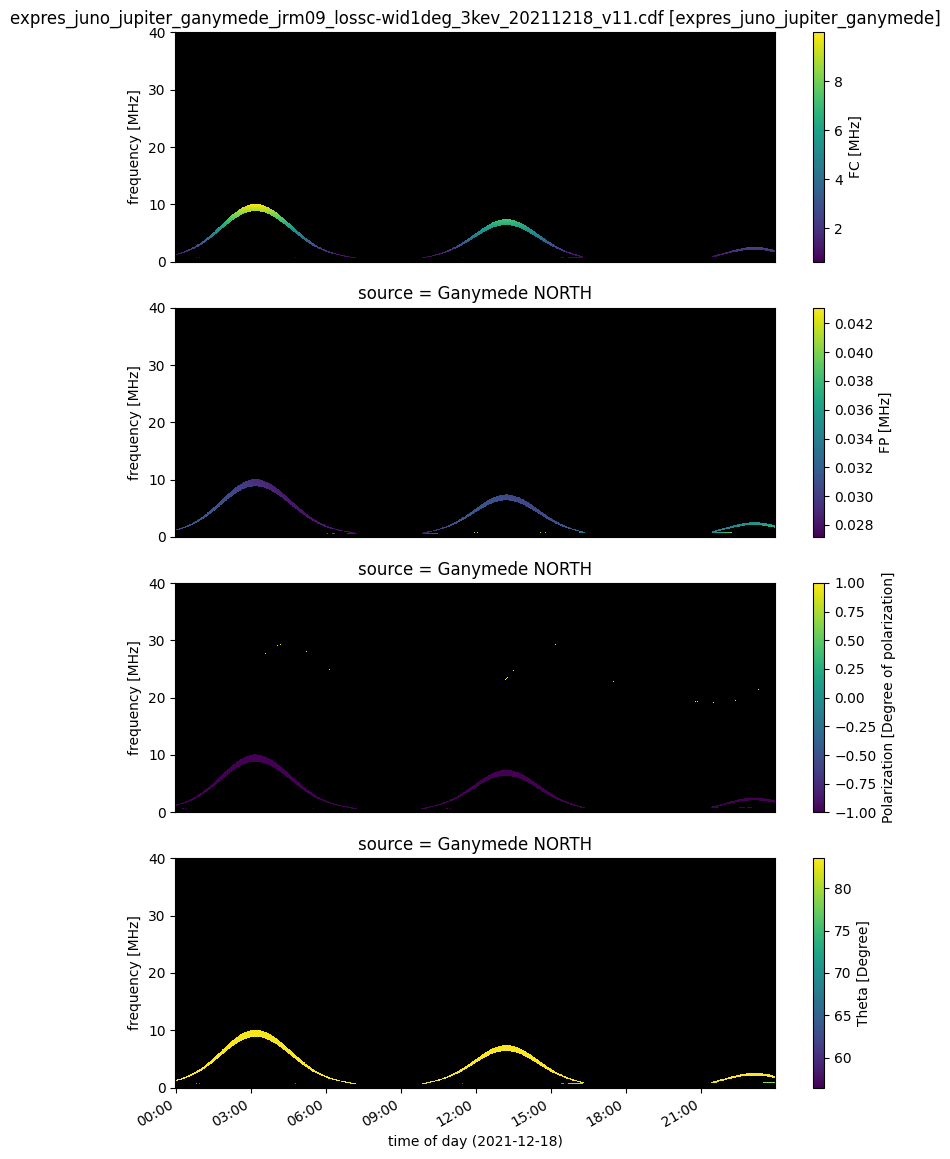

expres_earth


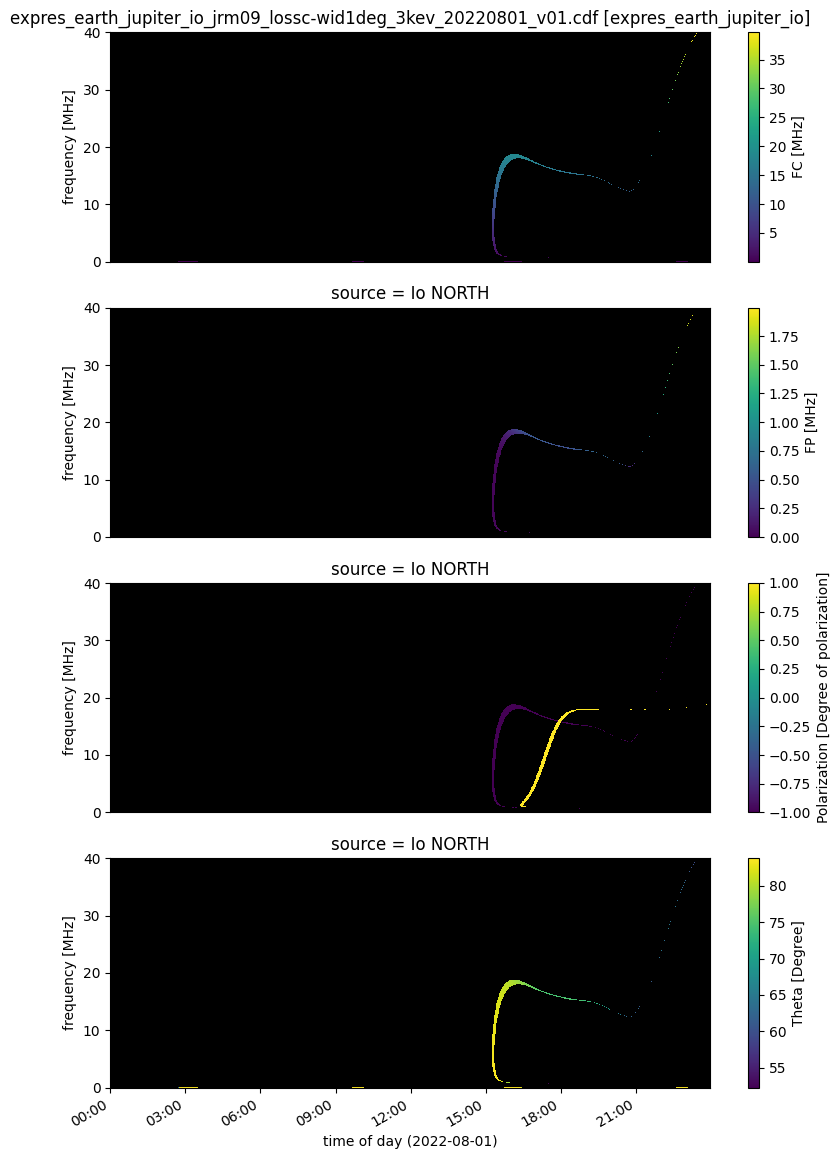

In [ ]:
for key in filenames.keys():
    if "expres" in key:
        print(key)
        if "ganymede" in filenames[key]["file"]:
            data = Data(base_dir + filenames[key]["file"], source="Ganymede NORTH")
        else:
            data = Data(base_dir + filenames[key]["file"], source="Io NORTH")
        data.quicklook(cmap="viridis")

And if you want to display everything (except expres datasets):

*Be careful this will take a long time/lot of memory*

In [ ]:
for key in filenames.keys():
    if "expres" not in key:
        print(key)
        data = Data(base_dir + filenames[key]["file"])
        # data.quicklook(cmap="viridis")  # uncomment for displaying all quicklooks

interball
stereoA_wave_LFR_l2
WindWaves_l2
ecallisto
NDA_routine_jupiter
NDA_routine_sun
NDA_newroutine_jupiter
NDA_newroutine_sun
NDA_mefisto
NenuFAR_BST
BepiColombo_PWI_sorbet_l1
Juno_Waves
Cassini_n1
Cassini_n2
Cassini_n3e
Cassini_n3d
SolO_RPW_L2_LFR
SolO_RPW_L2_TNR
SolO_RPW_L2_HFR
SolO_RPW_L3_TNR
SolO_RPW_L3_HFR
Stereo_Waves_L3
Wind_Waves_L3_akr
Wind_Waves_L3_df
Voyager1_J_PRA_6sec
Voyager1_J_PRA_48sec
Voyager1_S_PRA_6sec
Voyager2_N_PRA_6sec
MarsExpress_marsis


# Feedback needed

We are constantly adding new supported datasets, but if you have any requirements of find any bugs, please contact us!!

> <contact.maser@obspm.fr>

or directly add issues in our github:

> <https://github.com/maserlib/maser4py/issues>